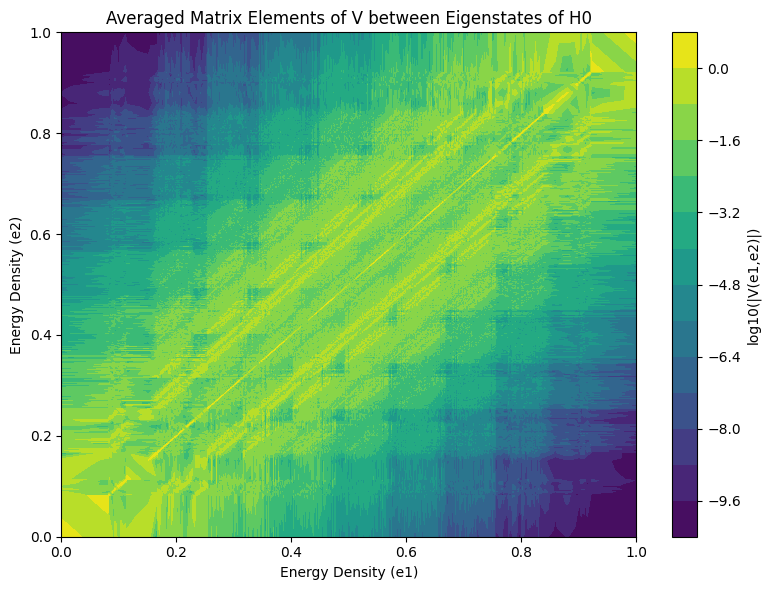

In [11]:
import numpy as np
import matplotlib.pyplot as plt

def construct_H0(Jz, hz, g, N):
    HZ = np.zeros((2**N, 2**N))
    for i in range(N):
        for j in range(i + 1, N):
            HZ += Jz[i, j] * np.kron(
                np.kron(np.eye(2**i), np.kron(np.array([[1, 0], [0, -1]]), np.eye(2**(j-i-1)))),
                np.kron(np.array([[1, 0], [0, -1]]), np.eye(2**(N-j-1)))
            )
    for i in range(N):
        HZ += hz[i] * np.kron(np.eye(2**i), np.kron(np.array([[1, 0], [0, -1]]), np.eye(2**(N-i-1))))

    HX = g * sum([np.kron(np.eye(2**i), np.kron(np.array([[0, 1], [1, 0]]), np.eye(2**(N-i-1)))) for i in range(N)])

    return HZ + HX

def construct_V0(Jz, hz, N):
    V0 = np.zeros((2**N, 2**N))
    for i in range(N):
        for j in range(i + 1, N):
            V0 += Jz[i, j] * np.kron(
                np.kron(np.eye(2**i), np.kron(np.array([[1, 0], [0, -1]]), np.eye(2**(j-i-1)))),
                np.kron(np.array([[1, 0], [0, -1]]), np.eye(2**(N-j-1)))
            )
    for i in range(N):
        V0 += hz[i] * np.kron(np.eye(2**i), np.kron(np.array([[1, 0], [0, -1]]), np.eye(2**(N-i-1))))

    return V0

# System parameters
N = 10 # Number of qubits
g = 1   # Transverse field
J = 1   # Variance for J_ij
num_realizations = 1

# Initialize array to store V matrix elements sorted by energy density
V_elements_list = []
energy_density_list = []

for realization in range(num_realizations):
    # Sample J_ij and h_i from their respective distributions
    Jz = np.random.normal(0, J**2 / N, size=(N, N))
    hz = np.random.normal(0, 1, size=N) * 2 / np.sqrt(N)

    # Ensure Jz is symmetric and zero-diagonal
    Jz = (Jz + Jz.T) / 2
    np.fill_diagonal(Jz, 0)

    # Construct the Hamiltonian H0 and the perturbation V0
    H0 = construct_H0(Jz, hz, g, N)
    V0 = construct_V0(Jz, hz, N)

    # Diagonalize the Hamiltonian
    eigenvalues, eigenstates = np.linalg.eigh(H0)
    # Calculate the energy densities of the eigenstates
    ground_energy = np.min(eigenvalues)
    excited_energy = np.max(eigenvalues)
    energy_densities = (eigenvalues - ground_energy) / (excited_energy - ground_energy)

    # Sort the matrix elements by energy density
    sorted_indices = np.argsort(energy_densities)
    eigenstates = eigenstates[:, sorted_indices]
    energy_densities = energy_densities[sorted_indices]

    # Compute the matrix elements of V0 in the eigenbasis of H0
    V_elements = np.abs(eigenstates.conj().T @ V0 @ eigenstates)

    # Store the sorted matrix elements
    V_elements_list.append(V_elements)
    energy_density_list.append(energy_densities)

# Average the V matrix elements over all realizations
avg_V_matrix_elements = np.mean(V_elements_list, axis=0)

# Flatten the energy densities and matrix elements to use with tricontourf
density_x, density_y = np.meshgrid(energy_densities, energy_densities)
density_x = density_x.flatten()
density_y = density_y.flatten()
V_elements_flat = avg_V_matrix_elements.flatten()

# Plot matrix elements of V as a function of energy densities
plt.figure(figsize=(8, 6))
# Use tricontourf to interpolate and plot the irregular grid data
# Use tricontourf to interpolate and plot the irregular grid data
contour = plt.tricontourf(density_x, density_y, np.log10(V_elements_flat + 1e-10), levels=14, cmap='viridis')

plt.colorbar(label='log10(|V(e1,e2)|)')
plt.xlabel('Energy Density (e1)')
plt.ylabel('Energy Density (e2)')
plt.title('Averaged Matrix Elements of V between Eigenstates of H0')
plt.tight_layout()  # Adjusts plot to ensure everything fits without overlapping
plt.show()

